In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv("PUF_data_SQL.csv")
print(df)

                 ProdDate Shift   TR NO MOULD NO ITEM NO  DENSITY  Thick   ID  \
0     2026-01-01 00:00:00     A  03477E  678/592   A-120      320   25.0  170   
1     2026-01-01 00:00:00     A  03477E  174/822   A-120      320   40.0  220   
2     2026-01-01 00:00:00     A  03477F    19/48    A-52      320   50.0  326   
3     2026-01-01 00:00:00     A  03477F       93    A-55      320   50.0  221   
4     2026-01-01 00:00:00     A  03477F       48    A-55      320   50.0  321   
...                   ...   ...     ...      ...     ...      ...    ...  ...   
5334  2026-04-01 00:00:00     A    3660      554    S-26      320   25.0   62   
5335  2026-04-01 00:00:00     A    3660      144    S-26      320   25.0  112   
5336  2026-04-01 00:00:00     A   3545G      261    P-27      160   65.0  170   
5337  2026-04-01 00:00:00     A  03545H      187   P-175      160   50.0   91   
5338  2026-04-01 00:00:00     A  03582A      111    D-20      320   50.0  116   

       OD  LENGTH  QTY  Uni

In [20]:
df.isnull().sum()

ProdDate                                         0
Shift                                            0
TR NO                                            0
MOULD NO                                         0
ITEM NO                                          0
DENSITY                                          0
Thick                                            0
ID                                               0
OD                                               0
LENGTH                                           0
QTY                                              0
Unit Design Weight ( 320 )                       0
Total Design Weight ( 320 )                      0
Unit Pouring Weight (304(320)+ Edge Cut Len)    81
Total Pouring Weight                             0
Unit Cut Weight                                 11
Total Cut weight                                11
Wastage                                         11
Pouring Weight Wastage                          50
Design Weight Wastage          

In [29]:
df.duplicated().sum()

np.int64(8)

In [31]:
df['ProdDate']= pd.to_datetime(df['ProdDate'])
df['Year']=df['ProdDate'].dt.year
df['Month']=df['ProdDate'].dt.month
df['Monthname']=df['ProdDate'].dt.strftime('%b')
print(df['ProdDate'],df['Year'],df['Month'],df['Monthname'])

0      2026-01-01
1      2026-01-01
2      2026-01-01
3      2026-01-01
4      2026-01-01
          ...    
5334   2026-04-01
5335   2026-04-01
5336   2026-04-01
5337   2026-04-01
5338   2026-04-01
Name: ProdDate, Length: 5339, dtype: datetime64[ns] 0       2026
1       2026
2       2026
3       2026
4       2026
        ... 
5334    2026
5335    2026
5336    2026
5337    2026
5338    2026
Name: Year, Length: 5339, dtype: int32 0       1
1       1
2       1
3       1
4       1
       ..
5334    4
5335    4
5336    4
5337    4
5338    4
Name: Month, Length: 5339, dtype: int32 0       Jan
1       Jan
2       Jan
3       Jan
4       Jan
       ... 
5334    Apr
5335    Apr
5336    Apr
5337    Apr
5338    Apr
Name: Monthname, Length: 5339, dtype: object


In [32]:
#Monthly Wastage Trend

In [34]:
monthly_wastage= df.groupby('Monthname')['Wastage'].mean()
print(monthly_wastage)

Monthname
Apr    4.282941
Feb    0.459560
Jan    0.552807
Mar    0.579977
Name: Wastage, dtype: float64


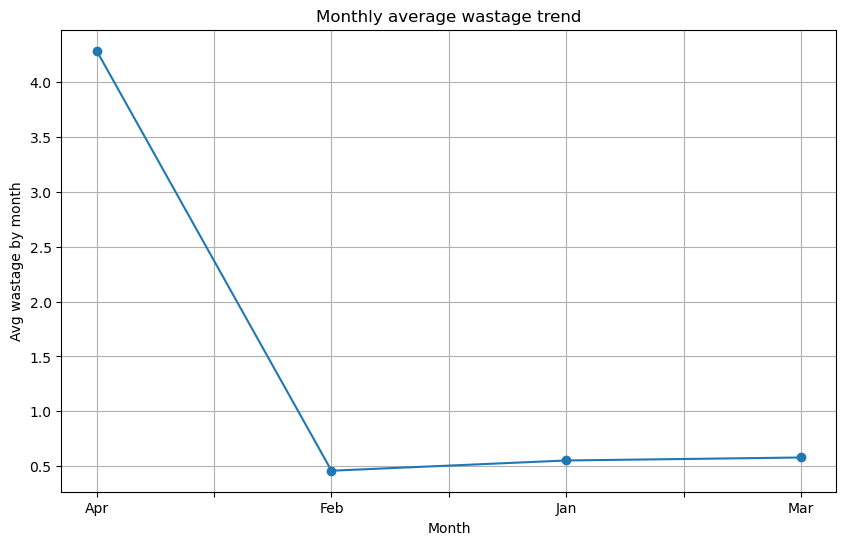

In [35]:
monthly_wastage.plot(kind='line',marker='o',figsize=(10,6))
plt.title('Monthly average wastage trend')
plt.ylabel('Avg wastage by month')
plt.xlabel('Month')
plt.grid(True)
plt.show()

In [36]:
#Shift wise wastage analysis

In [42]:
shift_quality = df.groupby('Shift')['Wastage'].mean()

print(shift_quality)

Shift
A    0.575457
B    0.543206
C    0.507193
Name: Wastage, dtype: float64


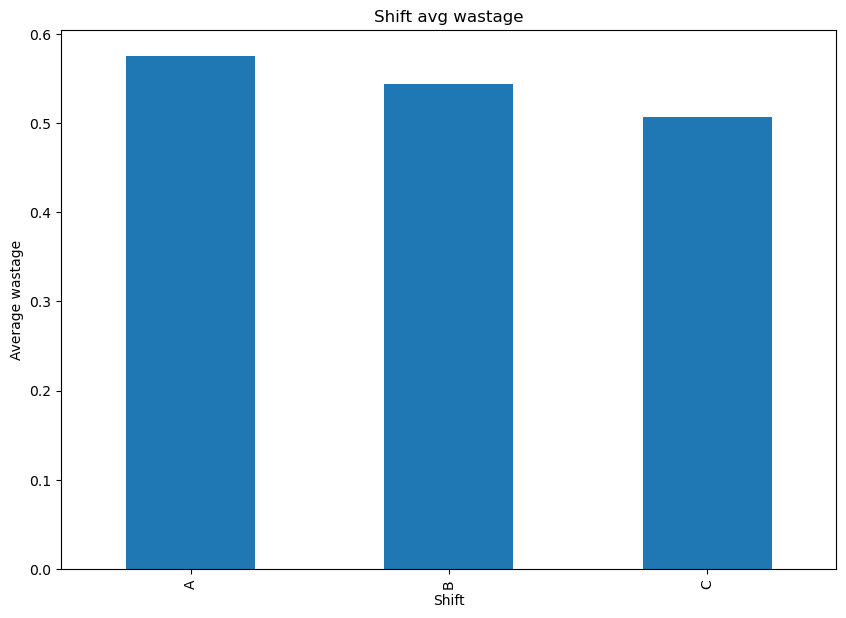

In [43]:
Shift_quality.plot(kind='bar',figsize=(10,7))
plt.title('Shift avg wastage')
plt.ylabel('Average wastage')
plt.xlabel('Shift')
plt.show()

In [44]:
#ITEM WISE Wastage analysis

In [50]:
Item_quality = df.groupby('ITEM NO')['Wastage'].mean()
top10 = Item_quality.sort_values(ascending= False).head(10)
print(top10)

ITEM NO
P-151    49.525172
P-134    37.662921
P-59     35.509547
S-13     20.494243
S-5      15.185805
F-205    10.400000
B-132    10.041080
P-37      9.663616
S-14      9.078348
P-48      9.075131
Name: Wastage, dtype: float64


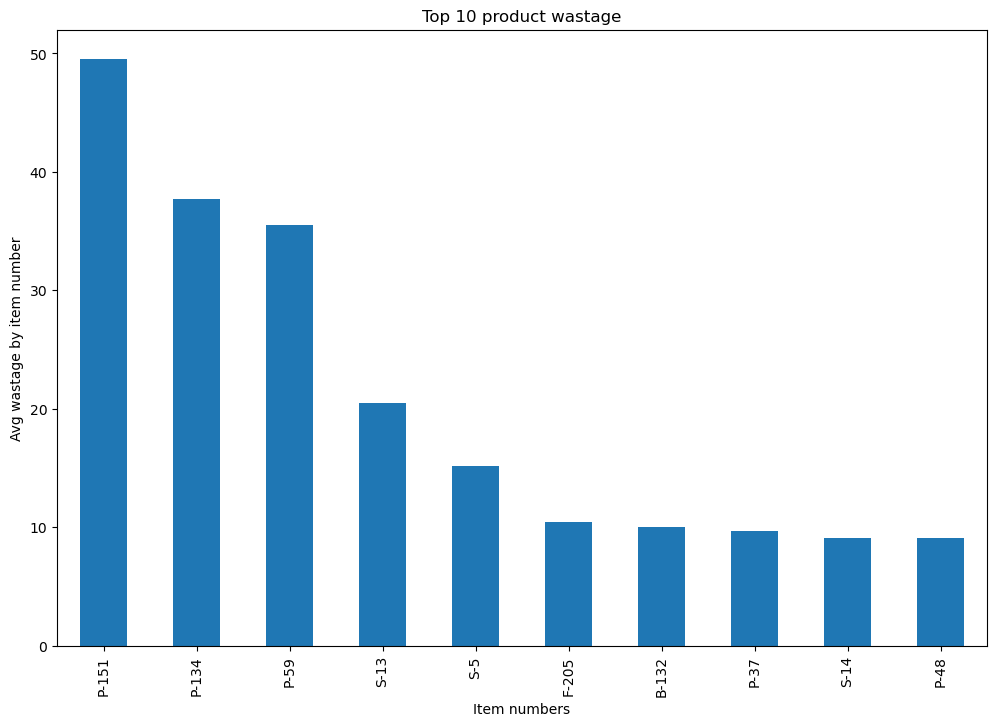

In [51]:
top10.plot(kind='bar',figsize=(12,8))
plt.title('Top 10 product wastage')
plt.xlabel('Item numbers')
plt.ylabel('Avg wastage by item number')
plt.show()

In [52]:
#Density Impact on Quality

In [58]:
Densitywise_wastage= df.groupby('DENSITY')['Wastage'].mean()
print(Densitywise_wastage)

DENSITY
160    0.419169
224    0.042307
240    0.106326
320    0.608843
500    1.695576
Name: Wastage, dtype: float64


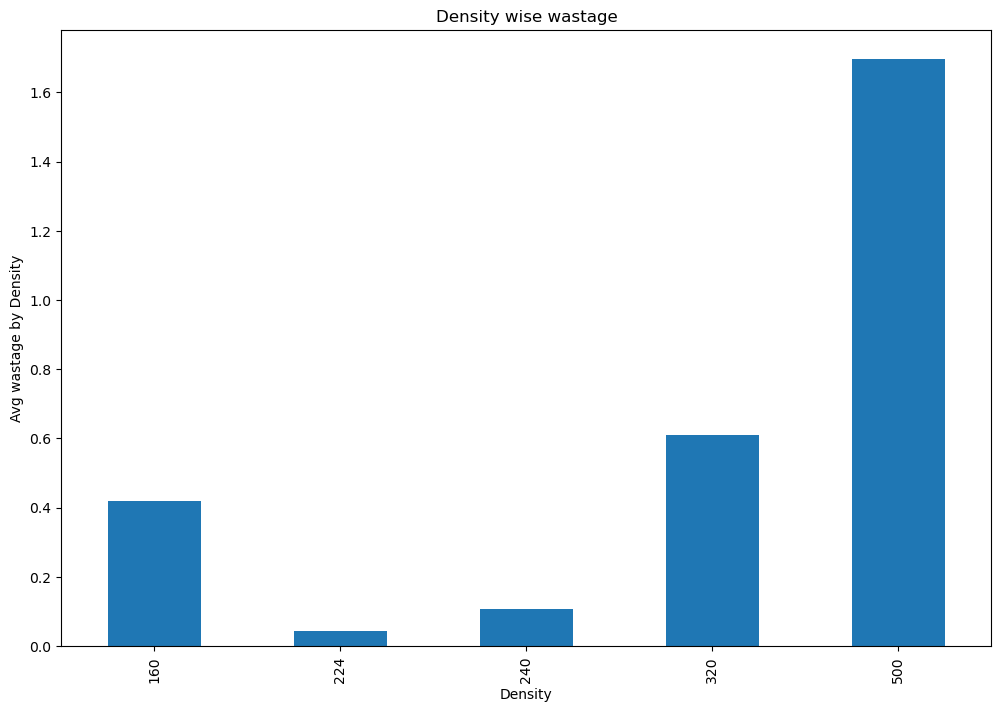

In [59]:
Densitywise_wastage.plot(kind='bar',figsize=(12,8))
plt.title('Density wise wastage')
plt.xlabel('Density')
plt.ylabel('Avg wastage by Density')
plt.show()

In [60]:
#Yield Efficiency Analysis


In [65]:
df['Yield_Percent'] = (
    df['Total Cut weight']
    / df['Total Pouring Weight']
)*100


In [66]:
df['Yield_Percent'].describe()

count    5323.000000
mean             inf
std              NaN
min         0.000000
25%        93.915191
50%        96.973896
75%        99.069370
max              inf
Name: Yield_Percent, dtype: float64

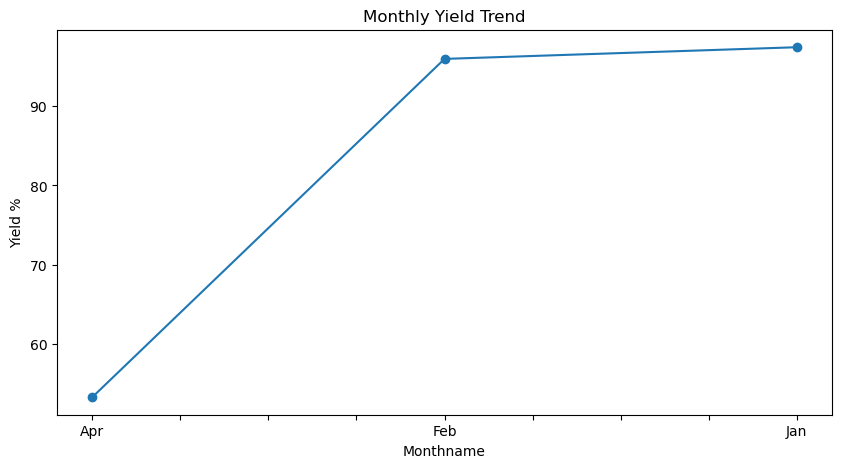

In [73]:
yield_trend = df.groupby(
    'Monthname'
)['Yield_Percent'].mean()

yield_trend.plot(
    kind='line',
    marker='o',
    figsize=(10,5)
)

plt.title("Monthly Yield Trend")
plt.ylabel("Yield %")

plt.show()

In [74]:
#Process Capability KPI


In [75]:
df['Quality_status']= np.where(
    df['Wastage'] <=0.5,
    'Good',
    'Poor'
)


In [79]:
df.head(10)

,ProdDate,Shift,TR NO,MOULD NO,ITEM NO,DENSITY,Thick,ID,OD,LENGTH,...,Unit Cut Weight,Total Cut weight,Wastage,Pouring Weight Wastage,Design Weight Wastage,Year,Month,Monthname,Yield_Percent,Quality_status
0,2026-01-01,A,03477E,678/592,A-120,320,25.0,170,220,450,...,1.12,4.48,0.028814,0.006391,0.006533,2026,1,Jan,99.360946,Good
1,2026-01-01,A,03477E,174/822,A-120,320,40.0,220,300,400,...,2.2,13.20,0.660000,0.047619,0.052605,2026,1,Jan,95.238095,Poor
2,2026-01-01,A,03477F,19/48,A-52,320,50.0,326,426,400,...,3.68,14.72,0.777854,0.050191,0.051446,2026,1,Jan,94.980895,Poor
3,2026-01-01,A,03477F,93,A-55,320,50.0,221,321,450,...,3.04,18.24,0.558285,0.029699,0.030359,2026,1,Jan,97.030127,Poor
4,2026-01-01,A,03477F,48,A-55,320,50.0,321,421,400,...,3.94,31.52,-0.936470,-0.030620,-0.031386,2026,1,Jan,103.062007,Good
5,2026-01-01,A,03477E,6,A-46,320,25.0,275,325,500,...,1.8,14.40,0.981238,0.063794,0.065070,2026,1,Jan,93.620555,Poor
6,2026-01-01,A,03477E,S-1,A-46,320,40.0,325,405,450,...,3.2,19.20,1.054979,0.052085,0.053242,2026,1,Jan,94.791509,Poor
7,2026-01-01,A,03477E,217,A-46,320,50.0,405,505,400,...,4.42,26.52,1.611077,0.057270,0.058702,2026,1,Jan,94.272963,Poor
8,2026-01-01,A,03477F,678/592,A-116,320,25.0,170,220,450,...,1.16,11.60,-0.327966,-0.029096,-0.029742,2026,1,Jan,102.909551,Good
9,2026-01-01,A,03477F,13,A-116,320,50.0,220,320,400,...,2.76,22.08,0.177556,0.007977,0.008177,2026,1,Jan,99.202268,Good


In [85]:
#Pareto Analysis(Identify biggest contributors to quality loss)

In [82]:
pareto= df.groupby('ITEM NO')['Wastage'].sum()
print(pareto)

ITEM NO
0         2.855090
1         0.086244
10        0.046258
100       4.484728
101       1.214688
           ...    
Z-6       4.233682
Z-7      13.045682
Z-8       1.657328
Z-9       1.067465
p-120     0.058583
Name: Wastage, Length: 787, dtype: float64


In [84]:
pareto.sort_values(ascending=False).head(20)

ITEM NO
N-63     124.486916
B-132    120.492965
S-13      81.976970
N-58      76.790207
S-5       60.743222
B-51      57.478321
B-75      57.265691
A-116     56.218782
B-57      49.638429
P-151     49.525172
B-23      46.923726
B-79      45.101449
B-27      44.942431
H-42      42.823520
A-6       42.486617
P-17      37.735841
P-134     37.662921
S-14      36.313393
P-59      35.509547
B-61      34.401384
Name: Wastage, dtype: float64

In [95]:
#Control Chart(Manufacturing companies love SPC)

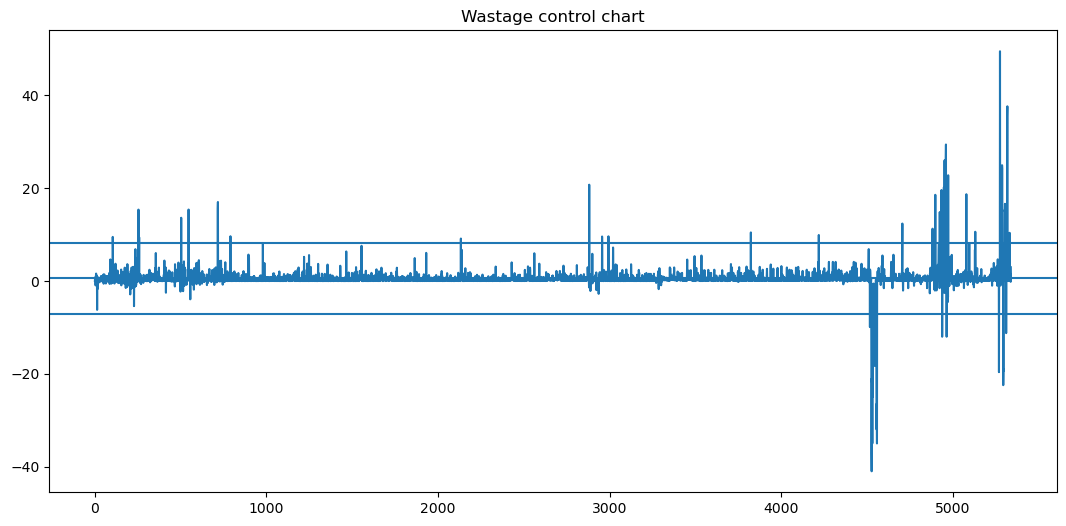

In [93]:
mean = df['Wastage'].mean()
std = df['Wastage'].std()

ucl = mean + 3*std
icl = mean - 3*std

plt.figure(figsize=(13,6))
plt.plot(df['Wastage'])

plt.axhline(mean)
plt.axhline(ucl)
plt.axhline(icl)

plt.title('Wastage control chart')
plt.show()


In [94]:
#Executive Summary(Generate KPI report)

In [96]:
print("Average_wastage:",round(df['Wastage'].mean(),2))
print("Maximum_wastage:",round(df['Wastage'].max(),2))
print("Average_yield:",round(df['Yield_Percent'].mean(),2))
print("Total_production:",round(df['QTY'].sum(),0))

Average_wastage: 0.55
Maximum_wastage: 49.53
Average_yield: inf
Total_production: 42318.0


In [100]:
df['Yield_Percent'].isnull()

0       False
1       False
2       False
3       False
4       False
        ...  
5334    False
5335    False
5336    False
5337    False
5338    False
Name: Yield_Percent, Length: 5339, dtype: bool